# LOAD MRI VOLUME


Loading MRI volume...

Expected Voxels = 11862016
Loaded Voxels = 11862016

MRI Volume Loaded Successfully!

MRI Shape = (181, 256, 256)

MRI Data Type = uint8

Minimum Intensity = 0
Maximum Intensity = 255

After Normalization:
Minimum = 0.0
Maximum = 1.0


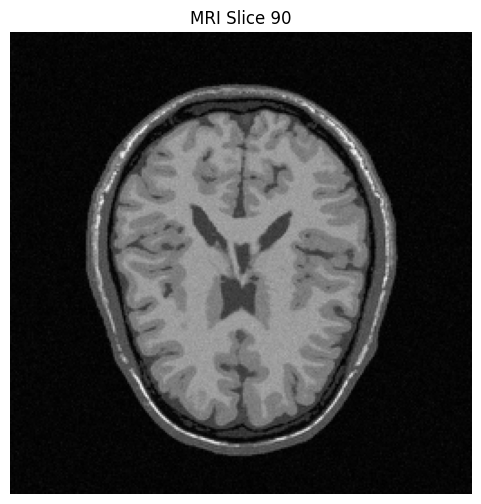


Example Voxel Value:
Voxel[90,120,100] = 0.5647059

MRI Volume Ready For 3D U-Net!


In [2]:
import numpy as np
import matplotlib.pyplot as plt

MRI_PATH = "subject04_t1w_p4.rawb"

DEPTH  = 181
HEIGHT = 256
WIDTH  = 256

print("\nLoading MRI volume...")

mri_volume = np.fromfile(
    MRI_PATH,
    dtype=np.uint8
)

expected_voxels = DEPTH * HEIGHT * WIDTH

print("\nExpected Voxels =", expected_voxels)

print("Loaded Voxels =", mri_volume.size)

if mri_volume.size != expected_voxels:

    raise ValueError(
        f"\nERROR:\n"
        f"Expected {expected_voxels} voxels "
        f"but found {mri_volume.size}"
    )

mri_volume = mri_volume.reshape(
    DEPTH,
    HEIGHT,
    WIDTH
)

print("\nMRI Volume Loaded Successfully!")

print("\nMRI Shape =", mri_volume.shape)

print("\nMRI Data Type =", mri_volume.dtype)

print("\nMinimum Intensity =", np.min(mri_volume))

print("Maximum Intensity =", np.max(mri_volume))

mri_volume = mri_volume.astype(np.float32)

mri_volume = mri_volume / 255.0

print("\nAfter Normalization:")

print("Minimum =", np.min(mri_volume))

print("Maximum =", np.max(mri_volume))

slice_index = DEPTH // 2

plt.figure(figsize=(6,6))

plt.imshow(
    mri_volume[slice_index],
    cmap='gray'
)

plt.title(f"MRI Slice {slice_index}")

plt.axis("off")

plt.show()

z = 90
y = 120
x = 100

voxel_value = mri_volume[z, y, x]

print("\nExample Voxel Value:")

print(f"Voxel[{z},{y},{x}] =", voxel_value)

print("\nMRI Volume Ready For 3D U-Net!")

Load Segmentation Label


Loading Ground Truth Volume...

Expected Voxels = 56873096
Loaded Voxels = 56873096

Original GT Shape = (362, 434, 362)

Unique Labels Present:
[ 0  1  2  3  4  5  6  7  8  9 10 11]


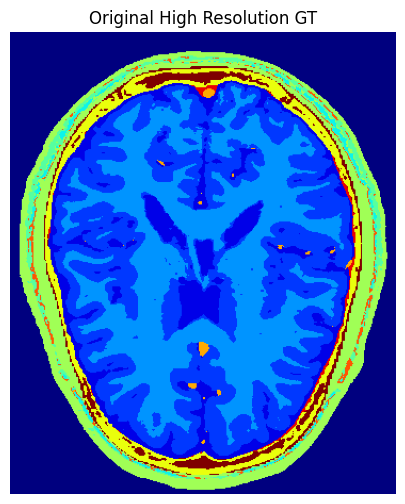


Resizing GT Volume...

Resized GT Shape = (181, 256, 256)


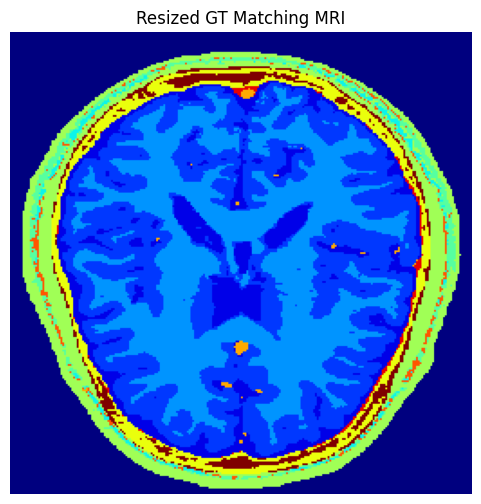


Ground Truth Volume Ready!


In [3]:
from scipy.ndimage import zoom

MASK_PATH = "/content/subject04_crisp_v.rawb"

GT_DEPTH  = 362
GT_HEIGHT = 434
GT_WIDTH  = 362

MRI_DEPTH  = 181
MRI_HEIGHT = 256
MRI_WIDTH  = 256

print("\nLoading Ground Truth Volume...")

mask_volume = np.fromfile(
    MASK_PATH,
    dtype=np.uint8
)

expected_voxels = (
    GT_DEPTH *
    GT_HEIGHT *
    GT_WIDTH
)

print("\nExpected Voxels =", expected_voxels)

print("Loaded Voxels =", mask_volume.size)

if mask_volume.size < expected_voxels:

    raise ValueError(
        f"\nERROR:\n"
        f"Expected {expected_voxels} voxels "
        f"but found {mask_volume.size}"
    )

mask_volume = mask_volume[:expected_voxels]

mask_volume = mask_volume.reshape(
    GT_DEPTH,
    GT_HEIGHT,
    GT_WIDTH
)

print("\nOriginal GT Shape =",
      mask_volume.shape)

print("\nUnique Labels Present:")

print(np.unique(mask_volume))

plt.figure(figsize=(6,6))

plt.imshow(
    mask_volume[180],
    cmap='jet'
)

plt.title("Original High Resolution GT")

plt.axis("off")

plt.show()

print("\nResizing GT Volume...")

scale_z = MRI_DEPTH / GT_DEPTH
scale_y = MRI_HEIGHT / GT_HEIGHT
scale_x = MRI_WIDTH / GT_WIDTH

mask_resized = zoom(
    mask_volume,
    (scale_z, scale_y, scale_x),
    order=0
)

print("\nResized GT Shape =",
      mask_resized.shape)

plt.figure(figsize=(6,6))

plt.imshow(
    mask_resized[90],
    cmap='jet'
)

plt.title("Resized GT Matching MRI")

plt.axis("off")

plt.show()

print("\nGround Truth Volume Ready!")

Preprocessing

In [1]:
import numpy as np
import matplotlib.pyplot as plt

MRI_PATH = "subject04_t1w_p4.rawb"

DEPTH  = 181
HEIGHT = 256
WIDTH  = 256

print("\nLoading MRI Volume...")

volume = np.fromfile(
    MRI_PATH,
    dtype=np.uint8
)

expected_voxels = (
    DEPTH *
    HEIGHT *
    WIDTH
)

print("\nExpected Voxels =", expected_voxels)

print("Loaded Voxels =", volume.size)

if volume.size != expected_voxels:

    raise ValueError(
        f"\nERROR:\n"
        f"Expected {expected_voxels} voxels "
        f"but found {volume.size}"
    )

volume = volume.reshape(
    DEPTH,
    HEIGHT,
    WIDTH
)

print("\nMRI Shape =", volume.shape)

print("\nConverting To Float32...")

volume = volume.astype(np.float32)

print("\nApplying Intensity Normalization...")

volume = volume / 255.0

print("\nMRI Intensity Range")

print("Minimum =", np.min(volume))

print("Maximum =", np.max(volume))

slice_index = DEPTH // 2

plt.figure(figsize=(6,6))

plt.imshow(
    volume[slice_index],
    cmap='gray'
)

plt.title("Normalized MRI")

plt.axis("off")

plt.show()

print("\nFinal MRI Information")

print("Shape =", volume.shape)

print("Minimum =", np.min(volume))

print("Maximum =", np.max(volume))

print("\nMRI Ready For 3D U-Net!")


Loading MRI Volume...


FileNotFoundError: [Errno 2] No such file or directory: 'subject04_t1w_p4.rawb'

Patch Extraction


MRI Shape = (181, 256, 256)
Resized Mask Shape = (181, 256, 256)

Extracting 3D Patches...

Total Valid Patches = 25

Image Patch Shape = (25, 64, 64, 64)
Mask Patch Shape = (25, 64, 64, 64)

One Patch Shape = (64, 64, 64)

Patch Intensity Range
Minimum = 0.0
Maximum = 0.85933477

Unique Labels In Mask Patches
[ 0  1  2  3  4  5  6  7  8  9 10 11]

Selecting Best Brain Patch...
Best Patch Index = 16


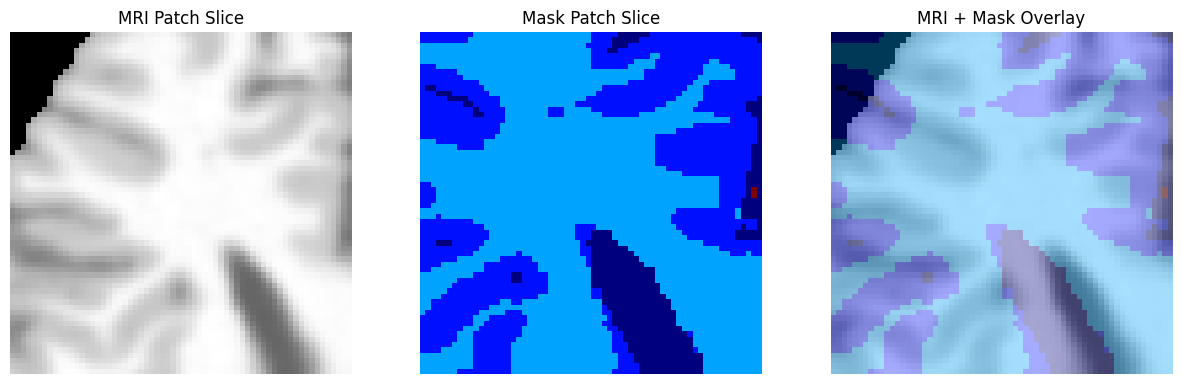


Patch Extraction Completed Successfully!

Ready For 3D U-Net Dataset Creation!

Final Dataset Information
Total Image Patches = 25
Total Mask Patches = 25
Patch Size = 64
Stride = 64


In [7]:
import numpy as np
import matplotlib.pyplot as plt

PATCH_SIZE = 64
STRIDE = 64

print("\nMRI Shape =", stripped_volume.shape)

print("Resized Mask Shape =", mask_resized.shape)

image_patches = []
mask_patches  = []

DEPTH, HEIGHT, WIDTH = stripped_volume.shape

print("\nExtracting 3D Patches...")

patch_count = 0

for z in range(
    0,
    DEPTH - PATCH_SIZE + 1,
    STRIDE
):

    for y in range(
        0,
        HEIGHT - PATCH_SIZE + 1,
        STRIDE
    ):

        for x in range(
            0,
            WIDTH - PATCH_SIZE + 1,
            STRIDE
        ):

            image_patch = stripped_volume[
                z:z+PATCH_SIZE,
                y:y+PATCH_SIZE,
                x:x+PATCH_SIZE
            ]

            mask_patch = mask_resized[
                z:z+PATCH_SIZE,
                y:y+PATCH_SIZE,
                x:x+PATCH_SIZE
            ]

            if np.sum(image_patch) > 50:

                image_patches.append(
                    image_patch
                )

                mask_patches.append(
                    mask_patch
                )

                patch_count += 1

print("\nTotal Valid Patches =",
      patch_count)

image_patches = np.array(
    image_patches,
    dtype=np.float32
)

mask_patches = np.array(
    mask_patches,
    dtype=np.uint8
)

print("\nImage Patch Shape =",
      image_patches.shape)

print("Mask Patch Shape =",
      mask_patches.shape)

print("\nOne Patch Shape =",
      image_patches[0].shape)

print("\nPatch Intensity Range")

print("Minimum =",
      np.min(image_patches))

print("Maximum =",
      np.max(image_patches))

print("\nUnique Labels In Mask Patches")

print(np.unique(mask_patches))

print("\nSelecting Best Brain Patch...")

best_patch_index = 0

max_intensity = 0

for i in range(len(image_patches)):

    patch_sum = np.sum(
        image_patches[i]
    )

    if patch_sum > max_intensity:

        max_intensity = patch_sum

        best_patch_index = i

print("Best Patch Index =",
      best_patch_index)

sample_patch = image_patches[
    best_patch_index
]

sample_mask = mask_patches[
    best_patch_index
]

middle_slice = PATCH_SIZE // 2

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)

plt.imshow(
    sample_patch[middle_slice],
    cmap='gray'
)

plt.title("MRI Patch Slice")

plt.axis("off")

plt.subplot(1,3,2)

plt.imshow(
    sample_mask[middle_slice],
    cmap='jet'
)

plt.title("Mask Patch Slice")

plt.axis("off")

plt.subplot(1,3,3)

plt.imshow(
    sample_patch[middle_slice],
    cmap='gray'
)

plt.imshow(
    sample_mask[middle_slice],
    cmap='jet',
    alpha=0.35
)

plt.title("MRI + Mask Overlay")

plt.axis("off")

plt.show()

print("\nPatch Extraction Completed Successfully!")

print("\nReady For 3D U-Net Dataset Creation!")

print("\nFinal Dataset Information")

print("Total Image Patches =",
      len(image_patches))

print("Total Mask Patches =",
      len(mask_patches))

print("Patch Size =",
      PATCH_SIZE)

print("Stride =",
      STRIDE)

Convert to Tensor

In [1]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

print("\nConverting Patches To PyTorch Tensors...")

image_patches = torch.tensor(
    image_patches,
    dtype=torch.float32
)

mask_patches = torch.tensor(
    mask_patches,
    dtype=torch.long
)

print("\nOriginal Image Patch Shape =",
      image_patches.shape)

print("Original Mask Patch Shape =",
      mask_patches.shape)

print("\nAdding Channel Dimension...")

image_patches = image_patches.unsqueeze(1)

print("\nTensor Shape After Channel Addition =",
      image_patches.shape)

print("\nTensor Dimension Meaning")

print("[Batch, Channel, Depth, Height, Width]")

print("\nExample:")

print(image_patches.shape)

print("\nDimension Interpretation")

print("Batch Size =", image_patches.shape[0])

print("Channels =", image_patches.shape[1])

print("Depth =", image_patches.shape[2])

print("Height =", image_patches.shape[3])

print("Width =", image_patches.shape[4])

print("\nCreating Custom Dataset...")

class BrainDataset(Dataset):

    def __init__(
        self,
        images,
        masks
    ):

        self.images = images
        self.masks = masks

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        image = self.images[idx]

        mask = self.masks[idx]

        return image, mask

dataset = BrainDataset(
    image_patches,
    mask_patches
)

print("\nDataset Size =",
      len(dataset))

BATCH_SIZE = 2

print("\nCreating DataLoader...")

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("\nLoading One Batch...")

for images, masks in loader:

    print("\nBatch Image Shape =",
          images.shape)

    print("Batch Mask Shape =",
          masks.shape)

    break

print("\nBatch Tensor Meaning")

print("[Batch, Channel, Depth, Height, Width]")

print("\nExample Batch Shape:")

print(images.shape)

print("\nExplanation")

print("Batch Size =", images.shape[0])

print("Channels =", images.shape[1])

print("Depth =", images.shape[2])

print("Height =", images.shape[3])

print("Width =", images.shape[4])

print("\nMask Tensor Shape")

print(masks.shape)

print("\nUnique Labels In Batch")

print(torch.unique(masks))

print("\nTensor Conversion Completed Successfully!")

print("\nReady For 3D U-Net Model Creation!")


Converting Patches To PyTorch Tensors...


NameError: name 'image_patches' is not defined

3D U-NET ARCHITECTURE

In [9]:
import torch
import torch.nn as nn

print("\nCreating 3D U-Net Architecture...")

class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

class UNet3D(nn.Module):

    def __init__(
        self,
        in_channels=1,
        out_channels=12
    ):

        super(UNet3D, self).__init__()

        print("\nBuilding Encoder Path...")

        self.enc1 = DoubleConv(
            in_channels,
            32
        )

        self.pool1 = nn.MaxPool3d(
            kernel_size=2
        )

        self.enc2 = DoubleConv(
            32,
            64
        )

        self.pool2 = nn.MaxPool3d(
            kernel_size=2
        )

        self.enc3 = DoubleConv(
            64,
            128
        )

        self.pool3 = nn.MaxPool3d(
            kernel_size=2
        )

        print("\nBuilding Bottleneck...")

        self.bottleneck = DoubleConv(
            128,
            256
        )

        print("\nBuilding Decoder Path...")

        self.up3 = nn.ConvTranspose3d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose3d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            128,
            64
        )

        self.up1 = nn.ConvTranspose3d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            64,
            32
        )

        print("\nCreating Final Output Layer...")

        self.final = nn.Conv3d(
            32,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        print("\nInput Shape =", x.shape)

        print("\nEncoder Level 1")

        e1 = self.enc1(x)

        print("After Conv =", e1.shape)

        p1 = self.pool1(e1)

        print("After Pool =", p1.shape)

        print("\nEncoder Level 2")

        e2 = self.enc2(p1)

        print("After Conv =", e2.shape)

        p2 = self.pool2(e2)

        print("After Pool =", p2.shape)

        print("\nEncoder Level 3")

        e3 = self.enc3(p2)

        print("After Conv =", e3.shape)

        p3 = self.pool3(e3)

        print("After Pool =", p3.shape)

        print("\nBottleneck")

        b = self.bottleneck(p3)

        print("Bottleneck Shape =", b.shape)

        print("\nDecoder Level 3")

        u3 = self.up3(b)

        print("After UpConv =", u3.shape)

        u3 = torch.cat(
            [u3, e3],
            dim=1
        )

        print("After Skip Connection =", u3.shape)

        d3 = self.dec3(u3)

        print("After Decoder Conv =", d3.shape)

        print("\nDecoder Level 2")

        u2 = self.up2(d3)

        print("After UpConv =", u2.shape)

        u2 = torch.cat(
            [u2, e2],
            dim=1
        )

        print("After Skip Connection =", u2.shape)

        d2 = self.dec2(u2)

        print("After Decoder Conv =", d2.shape)

        print("\nDecoder Level 1")

        u1 = self.up1(d2)

        print("After UpConv =", u1.shape)

        u1 = torch.cat(
            [u1, e1],
            dim=1
        )

        print("After Skip Connection =", u1.shape)

        d1 = self.dec1(u1)

        print("After Decoder Conv =", d1.shape)

        print("\nFinal Output Layer")

        out = self.final(d1)

        print("Output Shape =", out.shape)

        return out

print("\nInitializing 3D U-Net...")

model = UNet3D(
    in_channels=1,
    out_channels=12
)

print("\n3D U-Net Created Successfully!")

print("\nTesting Forward Pass...")

sample_input = torch.randn(
    2,
    1,
    64,
    64,
    64
)

output = model(sample_input)

print("\nForward Pass Completed!")

print("\nFinal Prediction Shape =",
      output.shape)

print("\nTensor Meaning")

print("[Batch, Classes, Depth, Height, Width]")

print("\nExample Output Shape:")

print(output.shape)

print("\nExplanation")

print("Batch Size =", output.shape[0])

print("Number Of Classes =", output.shape[1])

print("Depth =", output.shape[2])

print("Height =", output.shape[3])

print("Width =", output.shape[4])

print("\n3D U-Net Ready For Training!")


Creating 3D U-Net Architecture...

Initializing 3D U-Net...

Building Encoder Path...

Building Bottleneck...

Building Decoder Path...

Creating Final Output Layer...

3D U-Net Created Successfully!

Testing Forward Pass...

Input Shape = torch.Size([2, 1, 64, 64, 64])

Encoder Level 1
After Conv = torch.Size([2, 32, 64, 64, 64])
After Pool = torch.Size([2, 32, 32, 32, 32])

Encoder Level 2
After Conv = torch.Size([2, 64, 32, 32, 32])
After Pool = torch.Size([2, 64, 16, 16, 16])

Encoder Level 3
After Conv = torch.Size([2, 128, 16, 16, 16])
After Pool = torch.Size([2, 128, 8, 8, 8])

Bottleneck
Bottleneck Shape = torch.Size([2, 256, 8, 8, 8])

Decoder Level 3
After UpConv = torch.Size([2, 128, 16, 16, 16])
After Skip Connection = torch.Size([2, 256, 16, 16, 16])
After Decoder Conv = torch.Size([2, 128, 16, 16, 16])

Decoder Level 2
After UpConv = torch.Size([2, 64, 32, 32, 32])
After Skip Connection = torch.Size([2, 128, 32, 32, 32])
After Decoder Conv = torch.Size([2, 64, 32, 32, 32

Bottleneck

In [10]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

class UNet3D(nn.Module):

    def __init__(
        self,
        in_channels=1,
        out_channels=12
    ):

        super(UNet3D, self).__init__()

        self.enc1 = DoubleConv(
            in_channels,
            32
        )

        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv(
            32,
            64
        )

        self.pool2 = nn.MaxPool3d(2)

        self.enc3 = DoubleConv(
            64,
            128
        )

        self.pool3 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv(
            128,
            256
        )

        self.up3 = nn.ConvTranspose3d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose3d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            128,
            64
        )

        self.up1 = nn.ConvTranspose3d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            64,
            32
        )

        self.final = nn.Conv3d(
            32,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        print("\nInput Shape =", x.shape)

        print("\nEncoder Level 1")

        e1 = self.enc1(x)

        print("After Conv =", e1.shape)

        p1 = self.pool1(e1)

        print("After Pool =", p1.shape)

        print("\nEncoder Level 2")

        e2 = self.enc2(p1)

        print("After Conv =", e2.shape)

        p2 = self.pool2(e2)

        print("After Pool =", p2.shape)

        print("\nEncoder Level 3")

        e3 = self.enc3(p2)

        print("After Conv =", e3.shape)

        p3 = self.pool3(e3)

        print("After Pool =", p3.shape)

        print("\nBottleneck Stage")

        print("\nInput From Encoder:")

        print(
            "Feature Map Shape =",
            p3.shape
        )

        print("\nFeature Representation Before Bottleneck")

        print(
            "[Batch, Channels, Depth, Height, Width]"
        )

        print("\nExample:")

        print(p3.shape)

        print("\nApplying Bottleneck Double Convolution...")

        b = self.bottleneck(p3)

        print("\nBottleneck Output Shape =",
              b.shape)

        print("\nSpatial Dimensions")

        print(
            b.shape[2],
            "x",
            b.shape[3],
            "x",
            b.shape[4]
        )

        print("\nNumber Of Feature Channels =",
              b.shape[1])

        print("\nMeaning Of Bottleneck")

        print("""
At this stage the network learns:

1. Global brain anatomy

2. Long-range volumetric context

3. Tissue relationships

4. High-level semantic features

5. Deep structural representation

6. Spatial relationships between tissues
""")

        print("\nSpatial Compression")

        print("""
64³
→
32³
→
16³
→
8³
""")

        print("\nWhy Bottleneck Is Important")

        print("""
The bottleneck contains the deepest learned
representation of the 3D MRI patch.

At this stage the network has the largest
receptive field.

Each voxel feature now depends on a large
volumetric region of the brain.
""")

        print("\nExample Interpretation")

        print("""
The network can now understand:

- ventricle shape
- cortical structure
- white matter continuity
- tissue organization
- volumetric anatomical patterns
""")

        print("\nBottleneck Ready For Decoder Path!")

        print("\nDecoder Level 3")

        u3 = self.up3(b)

        print("After UpConv =", u3.shape)

        u3 = torch.cat(
            [u3, e3],
            dim=1
        )

        print("After Skip Connection =", u3.shape)

        d3 = self.dec3(u3)

        print("After Decoder Conv =", d3.shape)

        print("\nDecoder Level 2")

        u2 = self.up2(d3)

        print("After UpConv =", u2.shape)

        u2 = torch.cat(
            [u2, e2],
            dim=1
        )

        print("After Skip Connection =", u2.shape)

        d2 = self.dec2(u2)

        print("After Decoder Conv =", d2.shape)

        print("\nDecoder Level 1")

        u1 = self.up1(d2)

        print("After UpConv =", u1.shape)

        u1 = torch.cat(
            [u1, e1],
            dim=1
        )

        print("After Skip Connection =", u1.shape)

        d1 = self.dec1(u1)

        print("After Decoder Conv =", d1.shape)

        print("\nFinal Output Layer")

        out = self.final(d1)

        print("Output Shape =", out.shape)

        return out

print("\nInitializing 3D U-Net...")

model = UNet3D(
    in_channels=1,
    out_channels=12
)

print("\nCreating Sample Input Tensor...")

sample_input = torch.randn(
    2,
    1,
    64,
    64,
    64
)

print("\nRunning Forward Pass...")

output = model(sample_input)

print("\nForward Pass Completed!")

print("\nFinal Output Shape =",
      output.shape)

print("\n3D U-Net Ready For Training!")


Initializing 3D U-Net...

Creating Sample Input Tensor...

Running Forward Pass...

Input Shape = torch.Size([2, 1, 64, 64, 64])

Encoder Level 1
After Conv = torch.Size([2, 32, 64, 64, 64])
After Pool = torch.Size([2, 32, 32, 32, 32])

Encoder Level 2
After Conv = torch.Size([2, 64, 32, 32, 32])
After Pool = torch.Size([2, 64, 16, 16, 16])

Encoder Level 3
After Conv = torch.Size([2, 128, 16, 16, 16])
After Pool = torch.Size([2, 128, 8, 8, 8])

Bottleneck Stage

Input From Encoder:
Feature Map Shape = torch.Size([2, 128, 8, 8, 8])

Feature Representation Before Bottleneck
[Batch, Channels, Depth, Height, Width]

Example:
torch.Size([2, 128, 8, 8, 8])

Applying Bottleneck Double Convolution...

Bottleneck Output Shape = torch.Size([2, 256, 8, 8, 8])

Spatial Dimensions
8 x 8 x 8

Number Of Feature Channels = 256

Meaning Of Bottleneck

At this stage the network learns:

1. Global brain anatomy

2. Long-range volumetric context

3. Tissue relationships

4. High-level semantic features


Decoder path

In [11]:
import torch
import torch.nn as nn

print("\nCreating Decoder Path...")

class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

class DecoderBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels
    ):

        super(DecoderBlock, self).__init__()

        print("\nInitializing Decoder Block...")

        self.upconv = nn.ConvTranspose3d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(
            out_channels + skip_channels,
            out_channels
        )

    def forward(
        self,
        x,
        skip
    ):

        print("\nDecoder Input Shape =",
              x.shape)

        print("\nStep 1 — Transpose Convolution")

        x = self.upconv(x)

        print("After UpSampling =",
              x.shape)

        print("\nPurpose Of Transpose Conv3D")

        print("""
Restore spatial resolution:

8³
→
16³
""")

        print("\nSkip Connection Shape =",
              skip.shape)

        print("\nStep 2 — Concatenate Skip Connection")

        x = torch.cat(
            [x, skip],
            dim=1
        )

        print("After Concatenation =",
              x.shape)

        print("\nWhy Skip Connections Matter")

        print("""
Skip connections transfer:

1. Fine boundaries

2. Spatial details

3. Anatomical edges

4. Tissue structure information

5. High-resolution encoder features

from encoder to decoder.
""")

        print("\nWithout Skip Connections")

        print("""
Decoder would lose:

- cortex boundaries
- ventricle edges
- tissue precision
- small anatomical structures
""")

        print("\nStep 3 — Double Conv3D")

        x = self.conv(x)

        print("After DoubleConv =",
              x.shape)

        print("\nPurpose Of Conv3D")

        print("""
Learn:

- refined segmentation features
- tissue appearance
- anatomical consistency
- voxel-wise structure
""")

        print("\nDecoder Stage Completed!")

        return x

print("\nCreating Bottleneck Tensor...")

decoder_input = torch.randn(
    2,
    256,
    8,
    8,
    8
)

print("Decoder Input Shape =",
      decoder_input.shape)

print("\nCreating Encoder Skip Features...")

skip_tensor = torch.randn(
    2,
    128,
    16,
    16,
    16
)

print("Skip Tensor Shape =",
      skip_tensor.shape)

print("\nInitializing Decoder...")

decoder = DecoderBlock(
    in_channels=256,
    skip_channels=128,
    out_channels=128
)

print("\nRunning Decoder Forward Pass...")

decoder_output = decoder(
    decoder_input,
    skip_tensor
)

print("\nDecoder Output Shape =",
      decoder_output.shape)

print("\nDecoder Path Summary")

print("""
Operations:

Transpose Conv3D
→
Concatenate Skip Connection
→
Conv3D

Purpose:

1. Recover segmentation map

2. Restore spatial resolution

3. Recover anatomical details

4. Produce fine voxel segmentation

5. Combine deep semantic features
   with encoder spatial information
""")

print("\nSpatial Resolution Recovery")

print("""
8³
→
16³
→
32³
→
64³
""")

print("\nDecoder Path Ready!")


Creating Decoder Path...

Creating Bottleneck Tensor...
Decoder Input Shape = torch.Size([2, 256, 8, 8, 8])

Creating Encoder Skip Features...
Skip Tensor Shape = torch.Size([2, 128, 16, 16, 16])

Initializing Decoder...

Initializing Decoder Block...

Running Decoder Forward Pass...

Decoder Input Shape = torch.Size([2, 256, 8, 8, 8])

Step 1 — Transpose Convolution
After UpSampling = torch.Size([2, 128, 16, 16, 16])

Purpose Of Transpose Conv3D

Restore spatial resolution:

8³
→
16³


Skip Connection Shape = torch.Size([2, 128, 16, 16, 16])

Step 2 — Concatenate Skip Connection
After Concatenation = torch.Size([2, 256, 16, 16, 16])

Why Skip Connections Matter

Skip connections transfer:

1. Fine boundaries

2. Spatial details

3. Anatomical edges

4. Tissue structure information

5. High-resolution encoder features

from encoder to decoder.


Without Skip Connections

Decoder would lose:

- cortex boundaries
- ventricle edges
- tissue precision
- small anatomical structures


Step 

Output Layer

In [12]:
import torch
import torch.nn as nn

print("\nCreating Final Output Layer...")

BATCH_SIZE = 2

NUM_CLASSES = 4

DEPTH  = 64
HEIGHT = 64
WIDTH  = 64

print("\nDecoder Output Feature Map")

decoder_output = torch.randn(
    BATCH_SIZE,
    32,
    DEPTH,
    HEIGHT,
    WIDTH
)

print("Decoder Feature Shape =",
      decoder_output.shape)

print("\nMeaning")

print("""
[Batch, Channels, Depth, Height, Width]

32 channels contain learned segmentation features.
""")

print("\nCreating Final Conv3D Layer...")

final_layer = nn.Conv3d(
    in_channels=32,
    out_channels=NUM_CLASSES,
    kernel_size=1
)

print("\nApplying Final Output Layer...")

output = final_layer(
    decoder_output
)

print("\nFinal Output Shape =",
      output.shape)

print("\nOutput Tensor Meaning")

print("""
[Batch, Classes, Depth, Height, Width]
""")

print("\nExample Output Shape:")

print(output.shape)

print("\nDimension Interpretation")

print("Batch Size =",
      output.shape[0])

print("Number Of Classes =",
      output.shape[1])

print("Depth =",
      output.shape[2])

print("Height =",
      output.shape[3])

print("Width =",
      output.shape[4])

print("\nWhy out_channels = 4 ?")

print("""
Because segmentation contains:

0 → Background

1 → CSF

2 → Gray Matter (GM)

3 → White Matter (WM)
""")

print("\nVoxel-wise Prediction Example")

voxel_prediction = output[
    0,
    :,
    32,
    32,
    32
]

print("\nRaw Class Scores For One Voxel:")

print(voxel_prediction)

print("\nApplying Softmax...")

softmax = nn.Softmax(dim=1)

probabilities = softmax(output)

print("\nProbability Tensor Shape =",
      probabilities.shape)

print("\nExample Voxel Probabilities")

voxel_probabilities = probabilities[
    0,
    :,
    32,
    32,
    32
]

print(voxel_probabilities)

print("\nPredicted Class")

predicted_class = torch.argmax(
    voxel_probabilities
)

print(predicted_class)

print("\nMeaning")

print("""
The network predicts the tissue class
for every voxel in the 3D MRI patch.
""")

print("\nOutput Layer Purpose")

print("""
1. Convert learned features into classes

2. Produce voxel-wise predictions

3. Generate segmentation map

4. Assign tissue label to every voxel
""")

print("\nFinal Segmentation Output Ready!")


Creating Final Output Layer...

Decoder Output Feature Map
Decoder Feature Shape = torch.Size([2, 32, 64, 64, 64])

Meaning

[Batch, Channels, Depth, Height, Width]

32 channels contain learned segmentation features.


Creating Final Conv3D Layer...

Applying Final Output Layer...

Final Output Shape = torch.Size([2, 4, 64, 64, 64])

Output Tensor Meaning

[Batch, Classes, Depth, Height, Width]


Example Output Shape:
torch.Size([2, 4, 64, 64, 64])

Dimension Interpretation
Batch Size = 2
Number Of Classes = 4
Depth = 64
Height = 64
Width = 64

Why out_channels = 4 ?

Because segmentation contains:

0 → Background

1 → CSF

2 → Gray Matter (GM)

3 → White Matter (WM)


Voxel-wise Prediction Example

Raw Class Scores For One Voxel:
tensor([-0.0722,  0.4037,  0.5179,  0.4800], grad_fn=<SelectBackward0>)

Applying Softmax...

Probability Tensor Shape = torch.Size([2, 4, 64, 64, 64])

Example Voxel Probabilities
tensor([0.1626, 0.2617, 0.2933, 0.2824], grad_fn=<SelectBackward0>)

Predicte

Softmax Probability

In [13]:
import torch
import torch.nn as nn

print("\nCreating Example Network Output...")

BATCH_SIZE = 2

NUM_CLASSES = 4

DEPTH  = 64
HEIGHT = 64
WIDTH  = 64

output = torch.randn(
    BATCH_SIZE,
    NUM_CLASSES,
    DEPTH,
    HEIGHT,
    WIDTH
)

print("\nRaw Network Output Shape =",
      output.shape)

print("\nTensor Meaning")

print("""
[Batch, Classes, Depth, Height, Width]
""")

print("\nEach voxel contains raw class scores.")

print("\nExample Raw Scores For One Voxel")

voxel_scores = output[
    0,
    :,
    32,
    32,
    32
]

print(voxel_scores)

print("\nApplying Softmax Probability...")

softmax = nn.Softmax(dim=1)

probabilities = softmax(output)

print("\nProbability Tensor Shape =",
      probabilities.shape)

print("\nExample Voxel Probabilities")

voxel_probabilities = probabilities[
    0,
    :,
    32,
    32,
    32
]

print(voxel_probabilities)

print("\nProbability Sum")

print(torch.sum(voxel_probabilities))

print("\nClass Labels")

print("""
0 → Background
1 → CSF
2 → Gray Matter (GM)
3 → White Matter (WM)
""")

print("\nVoxel-wise Probability Interpretation")

print(f"Background Probability = "
      f"{voxel_probabilities[0]:.4f}")

print(f"CSF Probability = "
      f"{voxel_probabilities[1]:.4f}")

print(f"GM Probability = "
      f"{voxel_probabilities[2]:.4f}")

print(f"WM Probability = "
      f"{voxel_probabilities[3]:.4f}")

print("\nFinding Final Predicted Class...")

predicted_class = torch.argmax(
    voxel_probabilities
)

print("Predicted Class =",
      predicted_class.item())

print("\nPrediction Meaning")

if predicted_class == 0:

    print("Prediction = Background")

elif predicted_class == 1:

    print("Prediction = CSF")

elif predicted_class == 2:

    print("Prediction = Gray Matter")

elif predicted_class == 3:

    print("Prediction = White Matter")

print("\nWhy Softmax Is Important")

print("""
Softmax converts raw network scores
into probabilities between 0 and 1.

The probabilities indicate how confident
the network is for each tissue class.
""")

print("\nExample")

print("""
Background = 0.01
CSF        = 0.80
GM         = 0.15
WM         = 0.04

Prediction = CSF
""")

print("\nSoftmax Probability Stage Completed!")


Creating Example Network Output...

Raw Network Output Shape = torch.Size([2, 4, 64, 64, 64])

Tensor Meaning

[Batch, Classes, Depth, Height, Width]


Each voxel contains raw class scores.

Example Raw Scores For One Voxel
tensor([ 2.0548, -1.4867, -0.4636, -0.7817])

Applying Softmax Probability...

Probability Tensor Shape = torch.Size([2, 4, 64, 64, 64])

Example Voxel Probabilities
tensor([0.8560, 0.0248, 0.0690, 0.0502])

Probability Sum
tensor(1.0000)

Class Labels

0 → Background
1 → CSF
2 → Gray Matter (GM)
3 → White Matter (WM)


Voxel-wise Probability Interpretation
Background Probability = 0.8560
CSF Probability = 0.0248
GM Probability = 0.0690
WM Probability = 0.0502

Finding Final Predicted Class...
Predicted Class = 0

Prediction Meaning
Prediction = Background

Why Softmax Is Important

Softmax converts raw network scores
into probabilities between 0 and 1.

The probabilities indicate how confident
the network is for each tissue class.


Example

Background = 0.01
CSF 

Loss Function

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("\nCreating Example Prediction Tensor...")

BATCH_SIZE = 2

NUM_CLASSES = 4

DEPTH  = 64
HEIGHT = 64
WIDTH  = 64

predictions = torch.randn(
    BATCH_SIZE,
    NUM_CLASSES,
    DEPTH,
    HEIGHT,
    WIDTH,
    requires_grad=True
)

print("\nPrediction Tensor Shape =",
      predictions.shape)

print("\nCreating Ground Truth Labels...")

ground_truth = torch.randint(
    0,
    NUM_CLASSES,
    (
        BATCH_SIZE,
        DEPTH,
        HEIGHT,
        WIDTH
    )
)

print("\nGround Truth Shape =",
      ground_truth.shape)

print("\nApplying Softmax...")

probabilities = F.softmax(
    predictions,
    dim=1
)

print("\nProbability Tensor Shape =",
      probabilities.shape)

class DiceLoss(nn.Module):

    def __init__(
        self,
        smooth=1e-5
    ):

        super(DiceLoss, self).__init__()

        self.smooth = smooth

    def forward(
        self,
        predictions,
        targets
    ):

        print("\nInside Dice Loss")

        print("\nConverting Ground Truth To One-Hot Encoding...")

        targets_one_hot = F.one_hot(
            targets,
            NUM_CLASSES
        )

        print("One-Hot Shape =",
              targets_one_hot.shape)

        targets_one_hot = targets_one_hot.permute(
            0,
            4,
            1,
            2,
            3
        ).float()

        print("\nPermuted One-Hot Shape =",
              targets_one_hot.shape)

        print("\nFlattening Tensors...")

        predictions = predictions.contiguous().view(
            predictions.shape[0],
            predictions.shape[1],
            -1
        )

        targets_one_hot = targets_one_hot.contiguous().view(
            targets_one_hot.shape[0],
            targets_one_hot.shape[1],
            -1
        )

        print("Predictions Shape =",
              predictions.shape)

        print("Targets Shape =",
              targets_one_hot.shape)

        print("\nComputing Intersection...")

        intersection = (
            predictions *
            targets_one_hot
        ).sum(dim=2)

        print("Intersection Shape =",
              intersection.shape)

        print("\nComputing Union...")

        union = (
            predictions.sum(dim=2)
            +
            targets_one_hot.sum(dim=2)
        )

        print("Union Shape =",
              union.shape)

        print("\nDice Formula")

        print(
            "Dice = (2 * Intersection) / (Prediction + GroundTruth)"
        )

        dice_score = (
            2.0 * intersection + self.smooth
        ) / (
            union + self.smooth
        )

        print("\nDice Score Shape =",
              dice_score.shape)

        print("\nMean Dice Score =",
              dice_score.mean().item())

        dice_loss = 1 - dice_score.mean()

        return dice_loss

print("\nInitializing Dice Loss...")

dice_loss_function = DiceLoss()

print("\nComputing Dice Loss...")

dice_loss = dice_loss_function(
    probabilities,
    ground_truth
)

print("\nDice Loss Value =",
      dice_loss.item())

print("\nCreating CrossEntropy Loss...")

cross_entropy_loss_function = nn.CrossEntropyLoss()

cross_entropy_loss = cross_entropy_loss_function(
    predictions,
    ground_truth
)

print("\nCrossEntropy Loss Value =",
      cross_entropy_loss.item())

print("\nCombining Losses...")

combined_loss = (
    dice_loss +
    cross_entropy_loss
)

print("\nCombined Loss Value =",
      combined_loss.item())

print("\nWhy Dice Loss Is Important")

print("""
Dice Loss measures overlap between:

1. Predicted segmentation

2. Ground truth segmentation

It is very important for medical imaging
because segmentation datasets often have:

- class imbalance
- small structures
- sparse regions
""")

print("\nWhy CrossEntropy Helps")

print("""
CrossEntropy improves:

- voxel classification
- class separation
- probability learning
""")

print("\nWhy Combined Loss Works Best")

print("""
Dice Loss:
improves overlap quality

CrossEntropy:
improves classification stability

Together:
better segmentation performance
""")

print("\nFinal Combined Loss")

print("""
Loss = DiceLoss + CrossEntropyLoss
""")

print("\nLoss Function Ready For Training!")


Creating Example Prediction Tensor...

Prediction Tensor Shape = torch.Size([2, 4, 64, 64, 64])

Creating Ground Truth Labels...

Ground Truth Shape = torch.Size([2, 64, 64, 64])

Applying Softmax...

Probability Tensor Shape = torch.Size([2, 4, 64, 64, 64])

Initializing Dice Loss...

Computing Dice Loss...

Inside Dice Loss

Converting Ground Truth To One-Hot Encoding...
One-Hot Shape = torch.Size([2, 64, 64, 64, 4])

Permuted One-Hot Shape = torch.Size([2, 4, 64, 64, 64])

Flattening Tensors...
Predictions Shape = torch.Size([2, 4, 262144])
Targets Shape = torch.Size([2, 4, 262144])

Computing Intersection...
Intersection Shape = torch.Size([2, 4])

Computing Union...
Union Shape = torch.Size([2, 4])

Dice Formula
Dice = (2 * Intersection) / (Prediction + GroundTruth)

Dice Score Shape = torch.Size([2, 4])

Mean Dice Score = 0.2502048909664154

Dice Loss Value = 0.7497950792312622

Creating CrossEntropy Loss...

CrossEntropy Loss Value = 1.721153736114502

Combining Losses...

Comb

Backpropagation

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim

print("\nInitializing 3D U-Net...")

model = UNet3D(
    in_channels=1,
    out_channels=4
)

print("\nMoving Model To Device...")

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device =", DEVICE)

model = model.to(DEVICE)

print("\nCreating Optimizer...")

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("\nOptimizer Created Successfully!")

print("\nWhy Adam Optimizer?")

print("""
Adam is widely used in deep learning because:

1. Fast convergence

2. Adaptive learning rate

3. Stable optimization

4. Works well for medical imaging

5. Handles complex 3D CNN training
""")

print("\nLearning Rate")

print("""
lr = 1e-4

Small learning rate helps:

- stable training
- smooth convergence
- better segmentation learning
""")

print("\nCreating Example Input Batch...")

images = torch.randn(
    2,
    1,
    64,
    64,
    64
).to(DEVICE)

print("Image Batch Shape =",
      images.shape)

print("\nCreating Example Ground Truth...")

masks = torch.randint(
    0,
    4,
    (
        2,
        64,
        64,
        64
    )
).to(DEVICE)

print("Mask Shape =",
      masks.shape)

print("\nForward Propagation...")

outputs = model(images)

print("\nOutput Shape =",
      outputs.shape)

print("\nComputing CrossEntropy Loss...")

criterion = nn.CrossEntropyLoss()

loss = criterion(
    outputs,
    masks
)

print("\nLoss Value =",
      loss.item())

print("\nBackpropagation Step")

print("""
Training Workflow:

1. Forward Pass
2. Compute Loss
3. Backpropagation
4. Weight Update
""")

print("\nStep 1 — Zero Previous Gradients")

optimizer.zero_grad()

print("Previous gradients cleared.")

print("\nStep 2 — Backward Propagation")

loss.backward()

print("Gradients Computed Successfully!")

print("\nWhat Backpropagation Does")

print("""
Backpropagation computes:

∂Loss / ∂Weights

for every trainable parameter
inside the 3D U-Net.
""")

print("\nStep 3 — Updating Network Weights")

optimizer.step()

print("Weights Updated Successfully!")

print("\nMeaning Of Weight Update")

print("""
The optimizer modifies network weights
to reduce segmentation error.

After many iterations:

- Dice score improves
- tissue prediction improves
- segmentation becomes accurate
""")

print("\nTraining Iteration Completed!")

print("\n3D U-Net Ready For Full Training Loop!")


Initializing 3D U-Net...

Moving Model To Device...
Device = cpu

Creating Optimizer...

Optimizer Created Successfully!

Why Adam Optimizer?

Adam is widely used in deep learning because:

1. Fast convergence

2. Adaptive learning rate

3. Stable optimization

4. Works well for medical imaging

5. Handles complex 3D CNN training


Learning Rate

lr = 1e-4

Small learning rate helps:

- stable training
- smooth convergence
- better segmentation learning


Creating Example Input Batch...
Image Batch Shape = torch.Size([2, 1, 64, 64, 64])

Creating Example Ground Truth...
Mask Shape = torch.Size([2, 64, 64, 64])

Forward Propagation...

Input Shape = torch.Size([2, 1, 64, 64, 64])

Encoder Level 1
After Conv = torch.Size([2, 32, 64, 64, 64])
After Pool = torch.Size([2, 32, 32, 32, 32])

Encoder Level 2
After Conv = torch.Size([2, 64, 32, 32, 32])
After Pool = torch.Size([2, 64, 16, 16, 16])

Encoder Level 3
After Conv = torch.Size([2, 128, 16, 16, 16])
After Pool = torch.Size([2, 128, 8

Epoch Training

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("\nDevice =", DEVICE)

NUM_CLASSES = 12

class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

class UNet3D(nn.Module):

    def __init__(
        self,
        in_channels=1,
        out_channels=12
    ):

        super(UNet3D, self).__init__()

        self.enc1 = DoubleConv(
            in_channels,
            32
        )

        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv(
            32,
            64
        )

        self.pool2 = nn.MaxPool3d(2)

        self.enc3 = DoubleConv(
            64,
            128
        )

        self.pool3 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv(
            128,
            256
        )

        self.up3 = nn.ConvTranspose3d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose3d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            128,
            64
        )

        self.up1 = nn.ConvTranspose3d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            64,
            32
        )

        self.final = nn.Conv3d(
            32,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        e1 = self.enc1(x)

        p1 = self.pool1(e1)

        e2 = self.enc2(p1)

        p2 = self.pool2(e2)

        e3 = self.enc3(p2)

        p3 = self.pool3(e3)

        b = self.bottleneck(p3)

        u3 = self.up3(b)

        u3 = torch.cat(
            [u3, e3],
            dim=1
        )

        d3 = self.dec3(u3)

        u2 = self.up2(d3)

        u2 = torch.cat(
            [u2, e2],
            dim=1
        )

        d2 = self.dec2(u2)

        u1 = self.up1(d2)

        u1 = torch.cat(
            [u1, e1],
            dim=1
        )

        d1 = self.dec1(u1)

        out = self.final(d1)

        return out

print("\nCreating 3D U-Net...")

model = UNet3D(
    in_channels=1,
    out_channels=NUM_CLASSES
).to(DEVICE)

print("\nModel Created Successfully!")

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

EPOCHS = 5

print("\nChecking Unique Labels In Dataset...")

print(torch.unique(mask_patches))

print("\nStarting Training...")

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    for batch_index, (images, masks) in enumerate(loader):

        images = images.to(DEVICE)

        masks = masks.to(DEVICE)

        outputs = model(images)

        loss = criterion(
            outputs,
            masks
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        print(
            f"Batch {batch_index+1} "
            f"Loss = {loss.item():.4f}"
        )

    epoch_loss = (
        running_loss / len(loader)
    )

    print(
        f"\nEpoch {epoch+1} "
        f"Average Loss = "
        f"{epoch_loss:.4f}"
    )

print("\nTraining Completed Successfully!")

print("\nFinal Output Meaning")

print("""
Output Tensor Shape:

[Batch, Classes, Depth, Height, Width]

Example:

[2,12,64,64,64]

Meaning:

2   → batch size
12  → segmentation classes
64  → depth
64  → height
64  → width
""")

print("\n3D U-Net Training Finished!")


Device = cpu

Creating 3D U-Net...

Model Created Successfully!

Checking Unique Labels In Dataset...
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

Starting Training...

Epoch 1/5
Batch 1 Loss = 2.5143
Batch 2 Loss = 2.5375
Batch 3 Loss = 2.5371
Batch 4 Loss = 2.5319
Batch 5 Loss = 2.5028
Batch 6 Loss = 2.5059
Batch 7 Loss = 2.5514
Batch 8 Loss = 2.4915
Batch 9 Loss = 2.4763
Batch 10 Loss = 2.5073
Batch 11 Loss = 2.5236
Batch 12 Loss = 2.5251
Batch 13 Loss = 2.5129

Epoch 1 Average Loss = 2.5167

Epoch 2/5
Batch 1 Loss = 2.5204
Batch 2 Loss = 2.4826
Batch 3 Loss = 2.5166
Batch 4 Loss = 2.4896
Batch 5 Loss = 2.5504
Batch 6 Loss = 2.4229
Batch 7 Loss = 2.3871
Batch 8 Loss = 2.5048
Batch 9 Loss = 2.4827
Batch 10 Loss = 2.4873
Batch 11 Loss = 2.4870
Batch 12 Loss = 2.4534
Batch 13 Loss = 2.3677

Epoch 2 Average Loss = 2.4733

Epoch 3/5
Batch 1 Loss = 2.3820
Batch 2 Loss = 2.4501
Batch 3 Loss = 2.4848
Batch 4 Loss = 2.3988
Batch 5 Loss = 2.3790
Batch 6 Loss = 2.1911
Batch 7 Los

Inference


Device = cpu

MRI Volume Shape = (181, 256, 256)

Creating Empty Prediction Volume...

Starting Sliding Window Inference...
Processed Patch 1
Processed Patch 2
Processed Patch 3
Processed Patch 4
Processed Patch 5
Processed Patch 6
Processed Patch 7
Processed Patch 8
Processed Patch 9
Processed Patch 10
Processed Patch 11
Processed Patch 12
Processed Patch 13
Processed Patch 14
Processed Patch 15
Processed Patch 16
Processed Patch 17
Processed Patch 18
Processed Patch 19
Processed Patch 20
Processed Patch 21
Processed Patch 22
Processed Patch 23
Processed Patch 24
Processed Patch 25

Total Predicted Patches = 25

Averaging Overlapping Predictions...

Final Prediction Volume Shape = (12, 181, 256, 256)

Converting Probabilities To Labels...

Final Segmentation Shape = (181, 256, 256)

Unique Predicted Labels
[0 3 6]


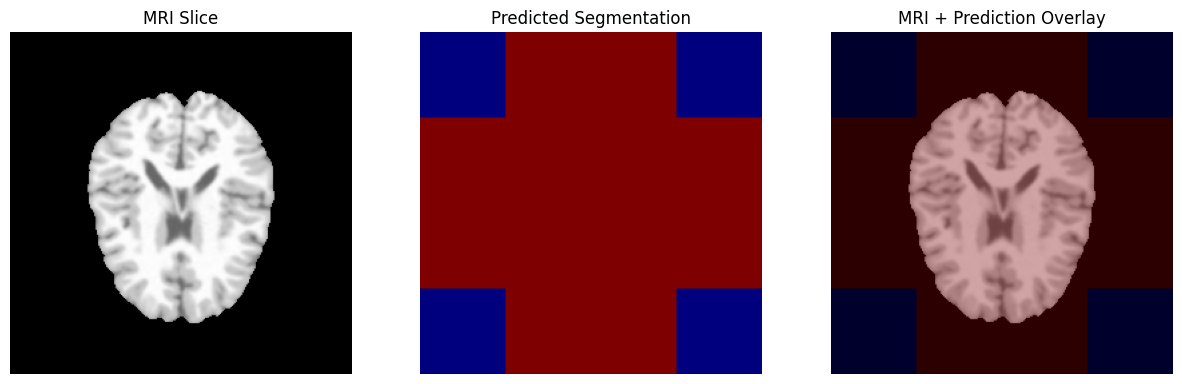


Inference Completed Successfully!

Sliding Window Prediction Workflow

Entire MRI Volume
↓
Extract 64³ Patch
↓
Predict Segmentation
↓
Move Sliding Window
↓
Predict Next Patch
↓
Combine Predictions
↓
Construct Full Brain Segmentation


3D Brain Segmentation Completed!


In [17]:
import numpy as np
import torch
import matplotlib.pyplot as plt

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("\nDevice =", DEVICE)

model.eval()

PATCH_SIZE = 64

STRIDE = 64

NUM_CLASSES = 12

DEPTH, HEIGHT, WIDTH = stripped_volume.shape

print("\nMRI Volume Shape =",
      stripped_volume.shape)

print("\nCreating Empty Prediction Volume...")

prediction_volume = np.zeros(
    (
        NUM_CLASSES,
        DEPTH,
        HEIGHT,
        WIDTH
    ),
    dtype=np.float32
)

count_volume = np.zeros(
    (
        DEPTH,
        HEIGHT,
        WIDTH
    ),
    dtype=np.float32
)

print("\nStarting Sliding Window Inference...")

patch_count = 0

with torch.no_grad():

    for z in range(
        0,
        DEPTH - PATCH_SIZE + 1,
        STRIDE
    ):

        for y in range(
            0,
            HEIGHT - PATCH_SIZE + 1,
            STRIDE
        ):

            for x in range(
                0,
                WIDTH - PATCH_SIZE + 1,
                STRIDE
            ):

                patch = stripped_volume[
                    z:z+PATCH_SIZE,
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ]

                if np.sum(patch) < 50:

                    continue

                patch_tensor = torch.tensor(
                    patch,
                    dtype=torch.float32
                )

                patch_tensor = patch_tensor.unsqueeze(0)

                patch_tensor = patch_tensor.unsqueeze(0)

                patch_tensor = patch_tensor.to(DEVICE)

                outputs = model(
                    patch_tensor
                )

                probabilities = torch.softmax(
                    outputs,
                    dim=1
                )

                probabilities = probabilities.cpu().numpy()[0]

                prediction_volume[
                    :,
                    z:z+PATCH_SIZE,
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ] += probabilities

                count_volume[
                    z:z+PATCH_SIZE,
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ] += 1

                patch_count += 1

                print(
                    f"Processed Patch {patch_count}"
                )

print("\nTotal Predicted Patches =",
      patch_count)

print("\nAveraging Overlapping Predictions...")

prediction_volume = prediction_volume / (
    count_volume[np.newaxis, ...] + 1e-8
)

print("\nFinal Prediction Volume Shape =",
      prediction_volume.shape)

print("\nConverting Probabilities To Labels...")

final_segmentation = np.argmax(
    prediction_volume,
    axis=0
)

print("\nFinal Segmentation Shape =",
      final_segmentation.shape)

print("\nUnique Predicted Labels")

print(np.unique(final_segmentation))

slice_index = DEPTH // 2

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)

plt.imshow(
    stripped_volume[slice_index],
    cmap='gray'
)

plt.title("MRI Slice")

plt.axis("off")

plt.subplot(1,3,2)

plt.imshow(
    final_segmentation[slice_index],
    cmap='jet'
)

plt.title("Predicted Segmentation")

plt.axis("off")

plt.subplot(1,3,3)

plt.imshow(
    stripped_volume[slice_index],
    cmap='gray'
)

plt.imshow(
    final_segmentation[slice_index],
    cmap='jet',
    alpha=0.35
)

plt.title("MRI + Prediction Overlay")

plt.axis("off")

plt.show()

print("\nInference Completed Successfully!")

print("\nSliding Window Prediction Workflow")

print("""
Entire MRI Volume
↓
Extract 64³ Patch
↓
Predict Segmentation
↓
Move Sliding Window
↓
Predict Next Patch
↓
Combine Predictions
↓
Construct Full Brain Segmentation
""")

print("\n3D Brain Segmentation Completed!")



Patch Reconstruction

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("\nSTEP 15 — Patch Reconstruction")

print("\nPurpose")

print("""
Merge all predicted 3D patches into:

Full Brain Segmentation Volume
""")

print("\nPrediction Volume Shape")

print(prediction_volume.shape)

print("\nCurrent Prediction Volume Meaning")

print("""
[Classes, Depth, Height, Width]
""")

print("\nCurrent Count Volume Shape")

print(count_volume.shape)

print("\nWhy Count Volume Is Needed")

print("""
Some voxels are predicted multiple times
because overlapping sliding windows are used.

count_volume stores:

how many predictions contributed
to each voxel.
""")

print("\nAveraging Overlapping Predictions...")

prediction_volume = prediction_volume / (
    count_volume[np.newaxis, ...] + 1e-8
)

print("\nReconstructed Probability Volume Shape =",
      prediction_volume.shape)

print("\nConverting Probability Maps To Labels...")

final_segmentation = np.argmax(
    prediction_volume,
    axis=0
)

print("\nFinal Segmentation Shape =",
      final_segmentation.shape)

print("\nFinal Volume Meaning")

print("""
[Depth, Height, Width]

Each voxel now contains:

predicted anatomical label
""")

print("\nUnique Labels In Final Segmentation")

print(np.unique(final_segmentation))

print("\nPatch Reconstruction Workflow")

print("""
Patch 1 Prediction
+
Patch 2 Prediction
+
Patch 3 Prediction
+
...
↓
Merge Overlapping Regions
↓
Average Predictions
↓
Construct Full 3D Segmentation Volume
""")

print("\nWhy Reconstruction Is Important")

print("""
3D U-Net predicts small patches individually.

Patch reconstruction combines all local
predictions into one global anatomical
segmentation of the entire MRI volume.
""")

slice_index = final_segmentation.shape[0] // 2

print("\nVisualizing Final Reconstruction...")

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)

plt.imshow(
    stripped_volume[slice_index],
    cmap='gray'
)

plt.title("Original MRI Slice")

plt.axis("off")

plt.subplot(1,3,2)

plt.imshow(
    final_segmentation[slice_index],
    cmap='jet'
)

plt.title("Reconstructed Segmentation")

plt.axis("off")

plt.subplot(1,3,3)

plt.imshow(
    stripped_volume[slice_index],
    cmap='gray'
)

plt.imshow(
    final_segmentation[slice_index],
    cmap='jet',
    alpha=0.35
)

plt.title("MRI + Final Overlay")

plt.axis("off")

plt.show()

print("\nPatch Reconstruction Completed Successfully!")

print("\nFinal Pipeline")

print("""
MRI Volume
↓
Patch Extraction
↓
3D U-Net Prediction
↓
Sliding Window Inference
↓
Patch Reconstruction
↓
Full Brain Segmentation
""")

print("\nFull 3D Brain Segmentation Ready!")

FINAL OUTPUT